In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pybaselines import Baseline, utils
from scipy.optimize import curve_fit
from sklearn.metrics import auc
from scipy.stats import linregress
from scipy.signal import  peak_widths
import scipy.integrate as integrate

In [2]:
path = "/Users/verityjanerothermelsmith/Downloads/CuGeGaS4/"
files = [file for file in os.listdir(path) if  file.endswith('.txt')]
dfs=[]
for file in sorted(files): 
    df = pd.read_csv(file, sep='\t', names=["eV", "intensity"])
    #print(file)
    #display(df)
    dfs.append(df[(df["eV"] >= 1.2) & (df["eV"] <= 2.1)])
power_list= [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.,  1.1, 1.2, 1.3, 1.4]


In [3]:


power_legend= [str(s)+" mW" for s in power_list]


In [4]:
for index, df in enumerate(dfs):
    x= df["eV"]
    y= df["intensity"]
    baseline_fitter = Baseline(x_data=x)
    bkg_1, params_1 = baseline_fitter.modpoly(y, poly_order=1)
    df["intensity-bkg"] = y - bkg_1

In [8]:
print(dfs)

[           eV  intensity  intensity-bkg
210   2.09979     1644.0     -44.607597
211   2.09856     1666.0     -22.666622
212   2.09733     1651.0     -37.725647
213   2.09610     1669.0     -19.784672
214   2.09487     1651.0     -37.843697
...       ...        ...            ...
1497  1.20161     1676.0     -55.709325
1498  1.20121     1671.0     -60.728520
1499  1.20081     1664.0     -67.747715
1500  1.20042     1672.0     -59.766430
1501  1.20002     1680.0     -51.785625

[1292 rows x 3 columns],            eV  intensity  intensity-bkg
210   2.09979     1702.0     -45.724772
211   2.09856     1709.0     -38.777506
212   2.09733     1714.0     -33.830241
213   2.09610     1725.0     -22.882975
214   2.09487     1717.0     -30.935709
...       ...        ...            ...
1497  1.20161     1724.0     -62.232846
1498  1.20121     1685.0    -101.249995
1499  1.20081     1722.0     -64.267145
1500  1.20042     1714.0     -72.283865
1501  1.20002     1717.0     -69.301015

[1292 rows x

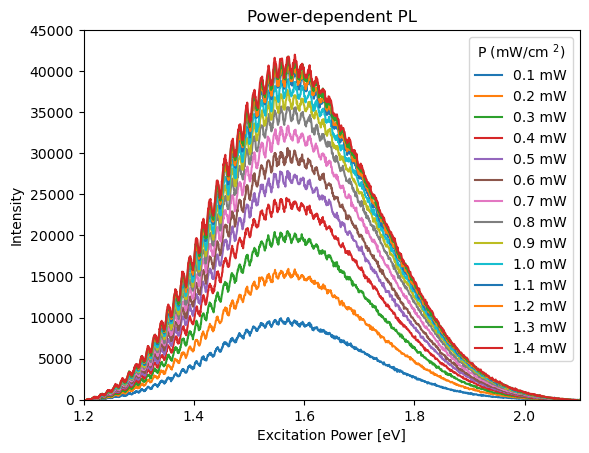

In [14]:
for index, df in enumerate(dfs):
    x= df["eV"]
    y= df["intensity"]
    y_corrected= df["intensity-bkg"]
    #plt.plot(x, y, label='raw data', lw=1.5)
    #plt.plot(x, bkg_1, '--', label='modpoly')
    plt.plot(x, y_corrected, '-',  label=power_legend[index])

    #plt.text(1.25, 35000, "CuGaSnS4", fontsize=10)
    #plt.text(1.25, 32000, "532 nm ", fontsize=10)

    #plt.show()
title="Power-dependent PL"
plt.title(title)
plt.legend(title="P (mW/cm $^2$)")
plt.ylabel("Intensity")
plt.xlabel("Excitation Power [eV]")
plt.ylim(0, 45000)
plt.xlim(1.2, 2.1)
plt.show()

### new approach

In [ ]:
#x, y inputs can be lists or 1D numpy arrays

def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/2/sigma**2)


def fit(x, y, power):
    params, cov = curve_fit(gauss, x, y, (1.6, .2, 20000)) 
    sigma=np.sqrt(np.diag(cov))
    x_fit = np.linspace(x.min(), x.max(), 500)
    #plot combined...
    #plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
    #...and individual Gauss curves
    peak_1= gauss(x_fit, *params[:3])
    # plt.plot(x_fit, peak_1, color='red', lw=1, ls="--", label='Gaussian fit')


    mu=params[0]
    sigma1=params[1]
    A= params[2]
    #alternative area under the curve
    def make_gauss(x):
        return A*np.exp(-(x-mu)**2/2/sigma1**2) 
    mu=params[0]

    A= params[2]
    result, error = integrate.quad(make_gauss, 1.2, 2.1)

    #and the original data points if no histogram has been created before
    # plt.plot(x, y, color="black", lw=1,ls="--",  label="baseline-corrected data")
    # plt.legend()
    # plt.title(f"{power} mW")

    
    params_df_1= pd.DataFrame(data={'params': params, 'sigma': sigma}, index=gauss.__code__.co_varnames[1:])


    # peak pos +- 2.355/2 * sigma
    fwhm_1_1 = params[0] - (2.355/2) * params[1]
    fwhm_1_2 = params[0] + (2.355/2) * params[1]
    fwhm= 2.355 * params[1]
    fwhm_error = fwhm*sigma[1]

    #final metrics
    peak_pos = params[0]
    peak_err = sigma[0]
    # plt.show() 

    return peak_pos, peak_err, result, error, fwhm, fwhm_error

expected_list=[(1.6, .2, 20000, 1.8, .2, 40000),(1.6, .2, 20000, 1.8, .2, 40000),(1.6, .2, 20000, 1.8, .2, 40000), 
               (1.6, .2, 20000, 1.8, .2, 40000), (1.6, .2, 15000, 1.8, .2, 35000),(1.6, .2, 15000, 1.8, .2, 35000),
               (1.6, .2, 15000, 1.8, .2, 35000), (1.6, .2, 15000, 1.8, .2, 35000), (1.6, .2, 15000, 1.8, .2, 35000),
               (1.6, .2, 15000, 1.8, .2, 35000),(1.6, .2, 15000, 1.8, .2, 35000), (1.6, .2, 20000, 1.8, .2, 35000),
               (1.6, .2, 20000, 1.8, .2, 35000)]


peak_pos_list= []
peak_err_list= []
area_list=[]
area_error_list=[]
fwhm_list=[]
fwhm_error_list=[]

for index, df in enumerate(dfs):
    y = df["intensity-bkg"]
    x= df["eV"]
    power= power_list[index]
    

    peak_pos, peak_err, result, error, fwhm, fwhm_error  = fit(x, y, power) 

    peak_pos_list.append(peak_pos)
    peak_err_list.append(peak_err)
    area_list.append(result)
    area_error_list.append(error)
    fwhm_list.append(fwhm)
    fwhm_error_list.append(fwhm_error)


# print(peak_pos_list)
# print(peak_err_list)
# print(area_list)
# print(area_error_list)
# print(fwhm_list)
# print(fwhm_error_list)
metrics = pd.DataFrame({'peak position': peak_pos_list,'peak position error': peak_err_list, 
                        'area': area_list,'area error': area_error_list,
                        'FWHM': fwhm_list,'FWHM error': fwhm_error_list,
                        })
display(metrics)

[np.float64(1.5746681721339806), np.float64(1.5786348418854952), np.float64(1.5808064762911296), np.float64(1.5815251655074647), np.float64(1.582463870503151), np.float64(1.5827261528903478), np.float64(1.5840997695231596), np.float64(1.585181499904695), np.float64(1.5855928554167358), np.float64(1.585622556717153), np.float64(1.5852834584339), np.float64(1.5854213382832278), np.float64(1.5854459908465435), np.float64(1.5854905555310226)]
[np.float64(0.00026311586928969575), np.float64(0.0002619449146358533), np.float64(0.00025804970891621533), np.float64(0.00025648141214049754), np.float64(0.0002630960676756686), np.float64(0.00026313810486031287), np.float64(0.0002633987959394223), np.float64(0.00026537417350696126), np.float64(0.0002680046025641404), np.float64(0.0002711809742006856), np.float64(0.0002728013845574183), np.float64(0.0002738945538762694), np.float64(0.0002783361636304901), np.float64(0.0002797692932429468)]
[3212.6262819979474, 5234.511031050544, 6848.507197266628, 82

,peak position,peak position error,area,area error,FWHM,FWHM error
0,1.574668,0.000263,3212.626282,7.608665e-11,0.320023,0.000083
1,1.578635,0.000262,5234.511031,1.097519e-10,0.322890,0.000083
2,1.580806,0.000258,6848.507197,1.303855e-10,0.324778,0.000083
3,1.581525,0.000256,8250.866448,1.481629e-10,0.325886,0.000082
4,1.582464,0.000263,9399.434938,1.568177e-10,0.327277,0.000085
5,1.582726,0.000263,10307.254601,1.643258e-10,0.328175,0.000085
6,1.584100,0.000263,11327.731614,1.681289e-10,0.329500,0.000085
7,1.585181,0.000265,12232.179162,1.698714e-10,0.330763,0.000086
8,1.585593,0.000268,12851.242229,1.709966e-10,0.331647,0.000088
9,1.585623,0.000271,13376.786572,1.727994e-10,0.332328,0.000089


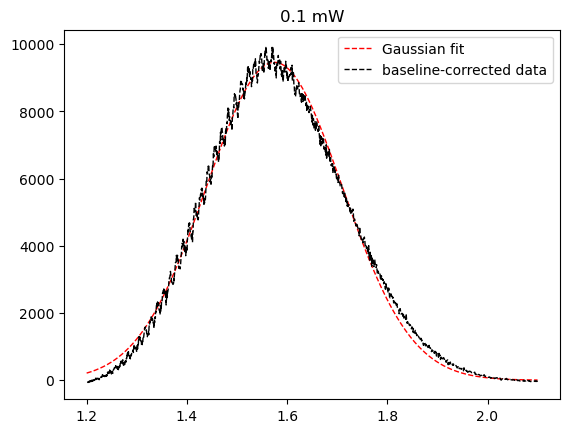

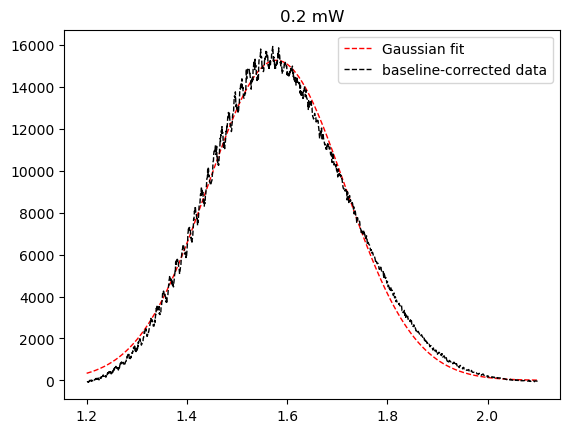

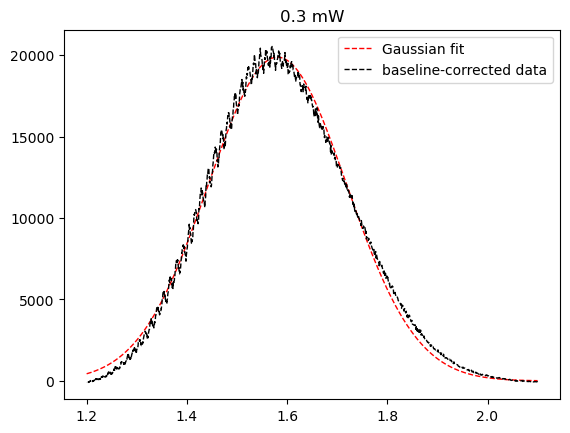

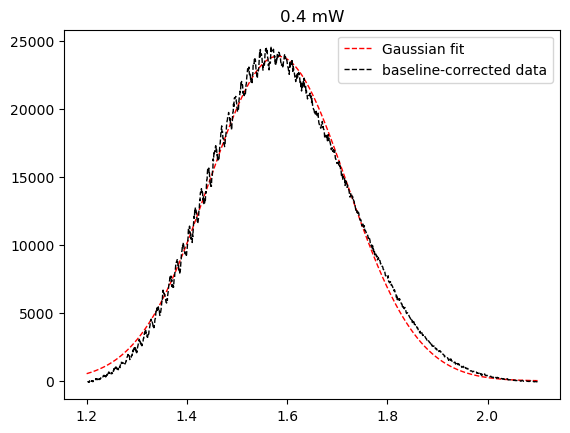

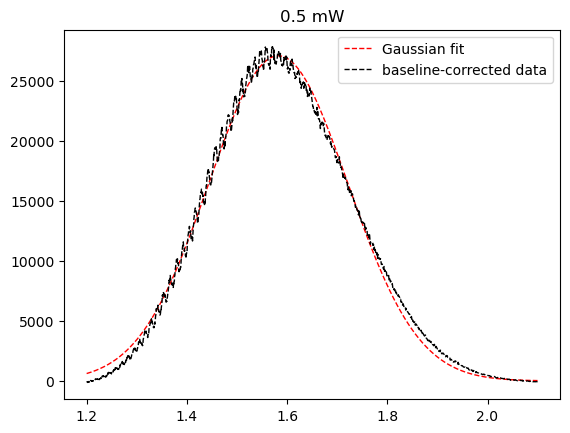

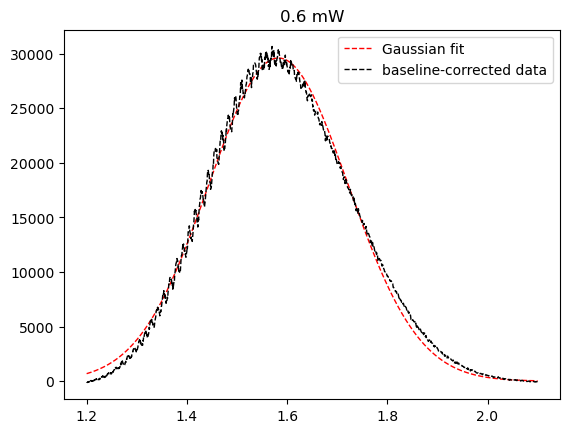

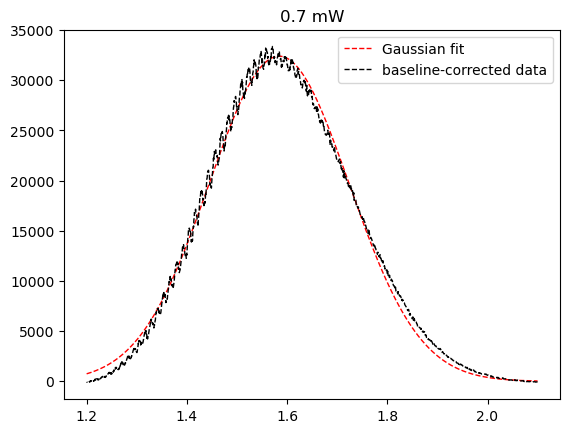

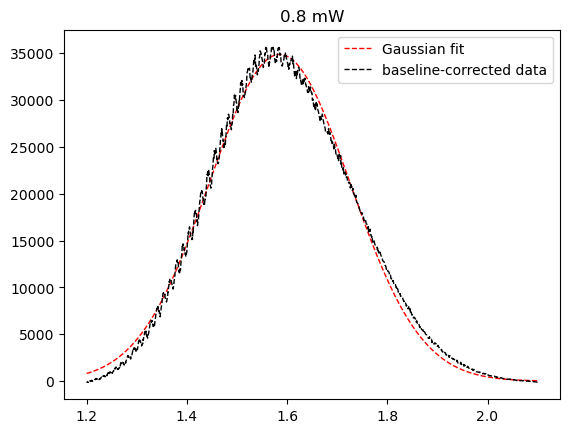

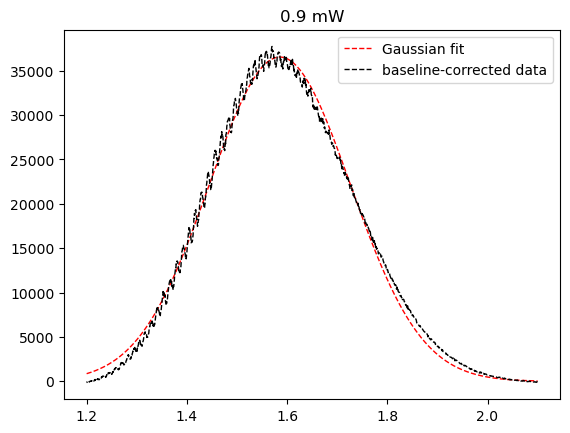

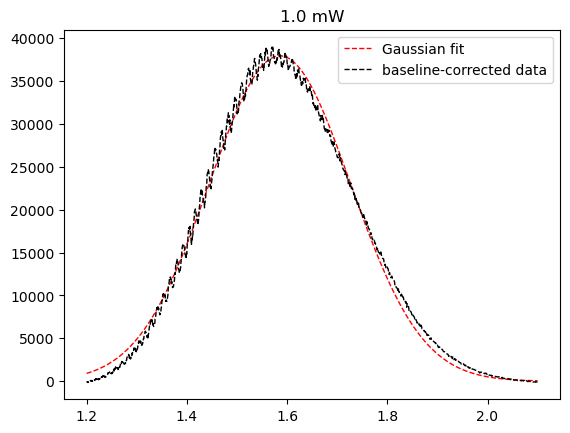

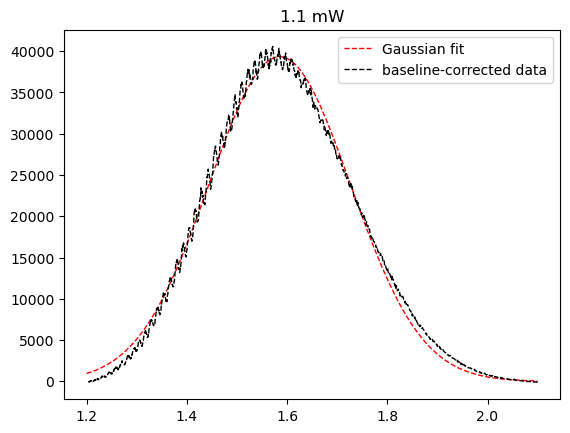

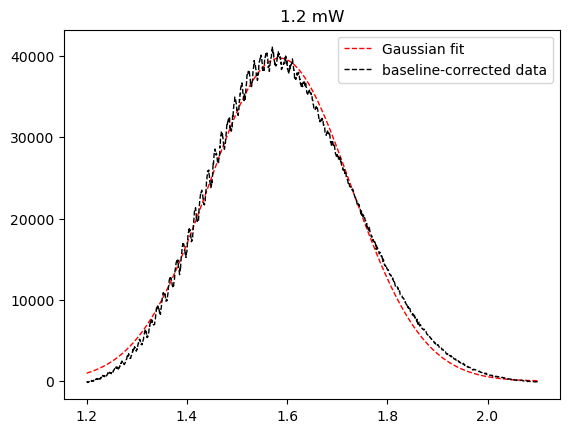

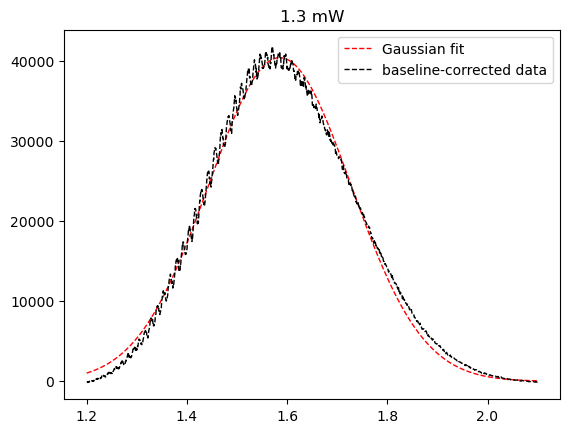

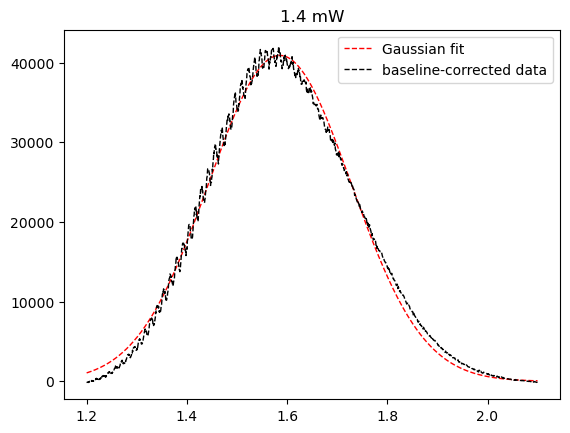

,params,sigma
mu,1.585491,0.000280
sigma,0.142422,0.000276
A,40892.238676,68.773472


In [ ]:
#x, y inputs can be lists or 1D numpy arrays

def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/2/sigma**2)

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

def fit(x, y, power):
    params, cov = curve_fit(gauss, x, y, (1.6, .2, 20000)) 
    sigma=np.sqrt(np.diag(cov))
    x_fit = np.linspace(x.min(), x.max(), 500)
    #plot combined...
    #plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
    #...and individual Gauss curves
    peak_1= gauss(x_fit, *params[:3])
    plt.plot(x_fit, peak_1, color='red', lw=1, ls="--", label='Gaussian fit')

    #area under curve
    peak_1_auc  = auc(x_fit, peak_1)

   

 

    #and the original data points if no histogram has been created before
    plt.plot(x, y, color="black", lw=1,ls="--",  label="baseline-corrected data")
    plt.legend()
    plt.title(f"{power} mW")

    
    params_df_1= pd.DataFrame(data={'params': params, 'sigma': sigma}, index=gauss.__code__.co_varnames[1:])


# peak pos +- 2.355/2 * sigma
    fwhm_1_1 = params[0] - (2.355/2) * params[1]
    fwhm_1_2 = params[0] + (2.355/2) * params[1]
    fwhm= 2.355 * params[1]
    fwhm_error = fwhm*sigma[1]



    plt.show() 

    
    #new_row = pd.DataFrame({"params": fwhm , "sigma": fwhm_error}, index="FWHM")
    #params_df_1 = pd.concat([params_df_1, new_row], ignore_index=True)
    return params_df_1, peak_1_auc

expected_list=[(1.6, .2, 20000, 1.8, .2, 40000),(1.6, .2, 20000, 1.8, .2, 40000),(1.6, .2, 20000, 1.8, .2, 40000), 
               (1.6, .2, 20000, 1.8, .2, 40000), (1.6, .2, 15000, 1.8, .2, 35000),(1.6, .2, 15000, 1.8, .2, 35000),
               (1.6, .2, 15000, 1.8, .2, 35000), (1.6, .2, 15000, 1.8, .2, 35000), (1.6, .2, 15000, 1.8, .2, 35000),
               (1.6, .2, 15000, 1.8, .2, 35000),(1.6, .2, 15000, 1.8, .2, 35000), (1.6, .2, 20000, 1.8, .2, 35000),
               (1.6, .2, 20000, 1.8, .2, 35000)]

peak_1_auc= []

params_peak_1= []



for index, df in enumerate(dfs):
    y = df["intensity-bkg"]
    x= df["eV"]
    power= power_list[index]
    

    params_df_1, peak_1  = fit(x, y, power) 

    peak_1_auc.append(peak_1)
    params_peak_1.append(params_df_1)

display(params_df_1)
    

    


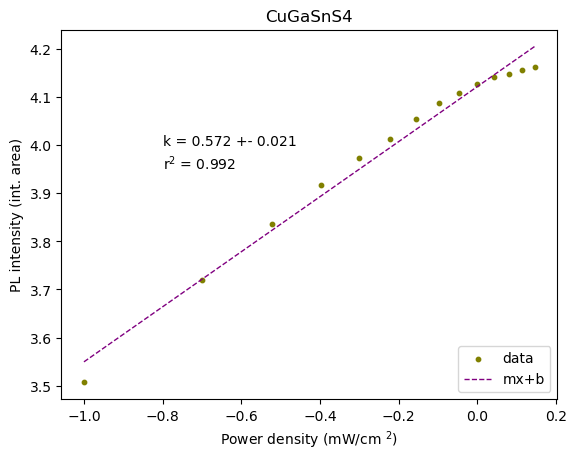

LinregressResult(slope=np.float64(0.5720960483419234), intercept=np.float64(4.121497996364482), rvalue=np.float64(0.9921813219832367), pvalue=np.float64(3.2434295574898003e-12), stderr=np.float64(0.020773916142263486), intercept_stderr=np.float64(0.008118081714712668))


In [ ]:
log_x = np.log10(power_list)
log_y= np.log10(peak_1_auc)

res = linregress(log_x, log_y) 
y_pred= res.slope * log_x + res.intercept

plt.scatter(log_x, log_y, marker='o', color='olive', s=10, label='data')
plt.plot(log_x, y_pred, color='purple', lw=1, ls="--", label='mx+b')
plt.legend(loc='lower right')
plt.xlabel("Power density (mW/cm $^2$)")
plt.ylabel("PL intensity (int. area)")
plt.text(-.8, 4, 'k = 0.572 +- 0.021', fontsize=10)
plt.text(-.8, 3.95, 'r$^2$ = 0.992', fontsize=10)
# plt.xscale('log')
# plt.yscale('log')
plt.title("CuGaSnS4")
plt.show()

print(res)